In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Only extract if not already extracted
if not os.path.exists('/content/data/mtcnn_splits/train'):
    print("Extracting dataset...")
    with zipfile.ZipFile('/content/drive/MyDrive/mtcnn_splits.zip', 'r') as z:
        z.extractall('/content')
    print("Extracted ✅")
else:
    print("Dataset already exists ✅")

# Verify
for split in ['train', 'val', 'test']:
    split_dir = f'/content/data/mtcnn_splits/{split}'
    total = sum(len(os.listdir(os.path.join(split_dir, a)))
                for a in os.listdir(split_dir))
    print(f"{split}: {total} images, {len(os.listdir(split_dir))} actors")

Mounted at /content/drive
Extracting dataset...
Extracted ✅
train: 16554 images, 100 actors
val: 3511 images, 100 actors
test: 3651 images, 100 actors


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

TRAIN_DIR   = '/content/data/mtcnn_splits/train'
VAL_DIR     = '/content/data/mtcnn_splits/val'
TEST_DIR    = '/content/data/mtcnn_splits/test'
SAVE_PATH   = '/content/drive/MyDrive/capstone_facerec/'
os.makedirs(SAVE_PATH, exist_ok=True)

IMG_SIZE    = (160, 160)
BATCH_SIZE  = 32
NUM_CLASSES = 100

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
def build_dataset(directory, augment=False):
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=augment,
        seed=42
    )
    def preprocess(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, 0.2)
            image = tf.image.random_contrast(image, 0.8, 1.2)
        return image, label
    return dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

train_ds = build_dataset(TRAIN_DIR, augment=True)
val_ds   = build_dataset(VAL_DIR,   augment=False)
test_ds  = build_dataset(TEST_DIR,  augment=False)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

Found 16554 files belonging to 100 classes.
Found 3511 files belonging to 100 classes.
Found 3651 files belonging to 100 classes.
Train batches : 518
Val batches   : 110
Test batches  : 115


In [5]:
def build_mobilenet(trainable_base=False, unfreeze_layers=0):
    base = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
    base.trainable = False
    if trainable_base and unfreeze_layers > 0:
        for layer in base.layers[-unfreeze_layers:]:
            layer.trainable = True

    inputs  = tf.keras.Input(shape=(160, 160, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs)

mobilenet_model = build_mobilenet(trainable_base=False)
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)
print("MobileNetV2 ready ✅")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 ready ✅


In [6]:
callbacks_mobilenet = [
    ModelCheckpoint(SAVE_PATH + 'mobilenet_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_mobilenet = mobilenet_model.fit(
    train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks_mobilenet
)

Epoch 1/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0966 - loss: 4.4399 - top5_accuracy: 0.2552
Epoch 1: val_accuracy improved from None to 0.29735, saving model to /content/drive/MyDrive/capstone_facerec/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/capstone_facerec/mobilenet_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 73s 99ms/step - accuracy: 0.1558 - loss: 3.9038 - top5_accuracy: 0.3679 - val_accuracy: 0.2974 - val_loss: 2.9650 - val_top5_accuracy: 0.5716 - learning_rate: 0.0010
Epoch 2/10
516/518 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3136 - loss: 2.8354 - top5_accuracy: 0.6029
Epoch 2: val_accuracy improved from 0.29735 to 0.35602, saving model to /content/drive/MyDrive/capstone_facerec/mobilenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/capstone_facerec/mobilenet_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.3204 - loss: 2.8130 - top5_accuracy: 0.6085 - val_accuracy: 0.3560 - va

In [7]:
results_mobilenet = mobilenet_model.evaluate(test_ds, verbose=0)
print("MobileNetV2 Results:")
print(f"  Top-1 Accuracy : {results_mobilenet[1]*100:.2f}%")
print(f"  Top-5 Accuracy : {results_mobilenet[2]*100:.2f}%")

MobileNetV2 Results:
  Top-1 Accuracy : 41.69%
  Top-5 Accuracy : 70.06%


In [8]:
!pip install keras-facenet -q

from keras_facenet import FaceNet

embedder      = FaceNet()
facenet_base  = embedder.model
facenet_base.trainable = False

inputs  = tf.keras.Input(shape=(160, 160, 3))
x       = facenet_base(inputs, training=False)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

facenet_model = models.Model(inputs, outputs)
facenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)
print("FaceNet ready ✅")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.8 MB/s eta 0:00:00
FaceNet ready ✅


In [9]:
callbacks_facenet = [
    ModelCheckpoint(SAVE_PATH + 'facenet_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_facenet = facenet_model.fit(
    train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks_facenet
)

Epoch 1/10
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3814 - loss: 2.8343 - top5_accuracy: 0.5834
Epoch 1: val_accuracy improved from None to 0.73854, saving model to /content/drive/MyDrive/capstone_facerec/facenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/capstone_facerec/facenet_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.5393 - loss: 2.0142 - top5_accuracy: 0.7465 - val_accuracy: 0.7385 - val_loss: 1.5759 - val_top5_accuracy: 0.8844 - learning_rate: 0.0010
Epoch 2/10
517/518 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6838 - loss: 1.3114 - top5_accuracy: 0.8556
Epoch 2: val_accuracy improved from 0.73854 to 0.75135, saving model to /content/drive/MyDrive/capstone_facerec/facenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/capstone_facerec/facenet_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - accuracy: 0.6907 - loss: 1.2829 - top5_accuracy: 0.8606 - val_accuracy: 0.7514 - val_loss:

In [10]:
results_facenet = facenet_model.evaluate(test_ds, verbose=0)
print("FaceNet Results:")
print(f"  Top-1 Accuracy : {results_facenet[1]*100:.2f}%")
print(f"  Top-5 Accuracy : {results_facenet[2]*100:.2f}%")

print("\n--- Model Comparison ---")
print(f"{'Model':<15} {'Top-1':>8} {'Top-5':>8}")
print(f"{'MobileNetV2':<15} {results_mobilenet[1]*100:>7.2f}% {results_mobilenet[2]*100:>7.2f}%")
print(f"{'FaceNet':<15} {results_facenet[1]*100:>7.2f}% {results_facenet[2]*100:>7.2f}%")

FaceNet Results:
  Top-1 Accuracy : 74.09%
  Top-5 Accuracy : 88.91%

--- Model Comparison ---
Model              Top-1    Top-5
MobileNetV2       41.69%   70.06%
FaceNet           74.09%   88.91%


In [12]:
facenet_base.trainable = True

for layer in facenet_base.layers[:-30]:
    layer.trainable = False

facenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

trainable     = sum([tf.size(w).numpy() for w in facenet_model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in facenet_model.non_trainable_weights])
print(f"Trainable     : {trainable:,}")
print(f"Non-trainable : {non_trainable:,}")
print("Ready for fine-tuning")

Trainable     : 3,260,644
Non-trainable : 20,290,128
Ready for fine-tuning


In [13]:
callbacks_finetune = [
    ModelCheckpoint(
        SAVE_PATH + 'facenet_finetuned_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_finetune = facenet_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_finetune,
    initial_epoch=10
)

Epoch 11/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7276 - loss: 1.0974 - top5_accuracy: 0.8838
Epoch 11: val_accuracy improved from None to 0.78696, saving model to /content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 85s 105ms/step - accuracy: 0.7431 - loss: 1.0227 - top5_accuracy: 0.8933 - val_accuracy: 0.7870 - val_loss: 0.8221 - val_top5_accuracy: 0.9177 - learning_rate: 1.0000e-04
Epoch 12/20
517/518 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8042 - loss: 0.7551 - top5_accuracy: 0.9271
Epoch 12: val_accuracy improved from 0.78696 to 0.81544, saving model to /content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras

Epoch 12: finished saving model to /content/drive/MyDrive/capstone_facerec/facenet_finetuned_best.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.8106 - loss: 0.7278 - top5_a

In [14]:
# Evaluate fine-tuned FaceNet
results_finetuned = facenet_model.evaluate(test_ds, verbose=0)

print("--- Final Model Comparison ---")
print(f"{'Model':<25} {'Top-1':>8} {'Top-5':>8}")
print(f"{'-'*45}")
print(f"{'MobileNetV2 (baseline)':<25} {results_mobilenet[1]*100:>7.2f}% {results_mobilenet[2]*100:>7.2f}%")
print(f"{'FaceNet (baseline)':<25} {results_facenet[1]*100:>7.2f}% {results_facenet[2]*100:>7.2f}%")
print(f"{'FaceNet (fine-tuned)':<25} {results_finetuned[1]*100:>7.2f}% {results_finetuned[2]*100:>7.2f}%")

--- Final Model Comparison ---
Model                        Top-1    Top-5
---------------------------------------------
MobileNetV2 (baseline)      41.69%   70.06%
FaceNet (baseline)          74.09%   88.91%
FaceNet (fine-tuned)        85.70%   94.96%


In [17]:
# Get class names from directory directly
import os

class_names = sorted(os.listdir(TEST_DIR))
print(f"Total classes : {len(class_names)}")
print(f"Sample classes: {class_names[:5]}")

Total classes : 100
Sample classes: ['ANR', 'AamairKhan', 'Aarthi', 'AkshayKumar', 'Ali']


In [18]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = facenet_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Total test samples : {len(y_true)}")
print(f"Total classes      : {len(class_names)}")

Total test samples : 3651
Total classes      : 100


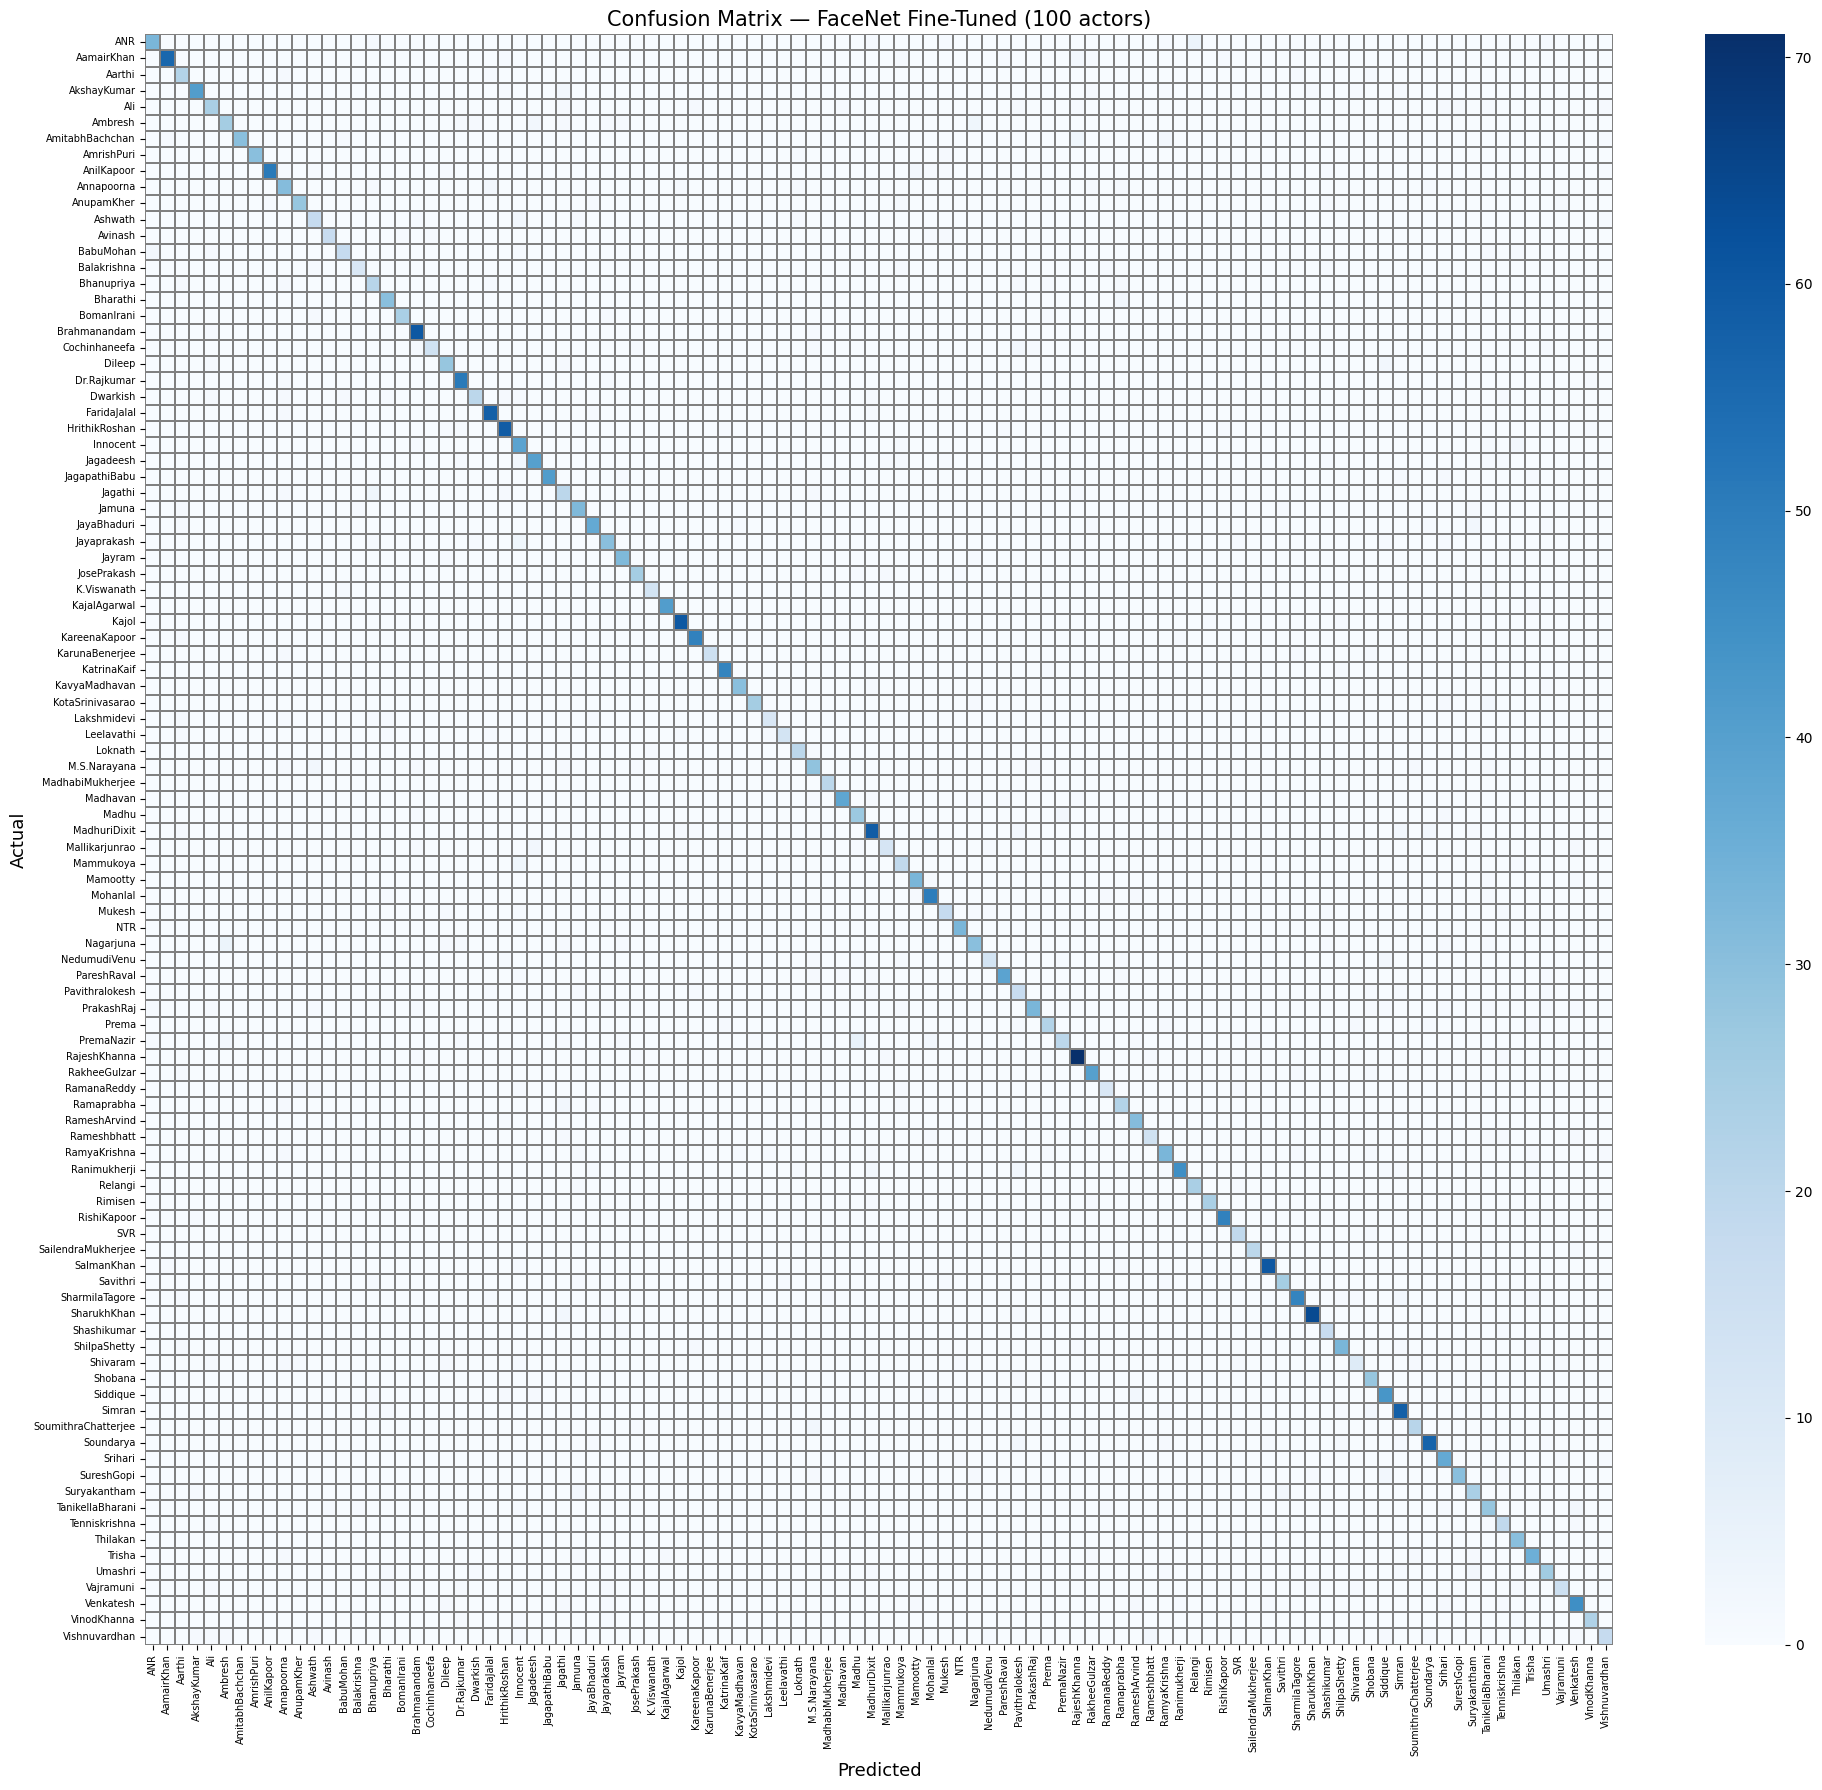

Saved to Drive ✅


In [19]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    linewidths=0.3,
    linecolor='gray'
)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix — FaceNet Fine-Tuned (100 actors)', fontsize=15)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix.png', dpi=150)
plt.show()
print("Saved to Drive ✅")

In [20]:
# Full classification report
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

# Top 5 best performing actors
print("Top 5 best recognized actors:")
actor_scores = {k: v['f1-score'] for k, v in report.items() if k in class_names}
for actor, score in sorted(actor_scores.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {actor:<25} F1: {score:.3f}")

# Bottom 5 worst performing actors
print("\nBottom 5 hardest actors to recognize:")
for actor, score in sorted(actor_scores.items(), key=lambda x: x[1])[:5]:
    print(f"  {actor:<25} F1: {score:.3f}")

# Overall stats
print(f"\nOverall accuracy  : {report['accuracy']*100:.2f}%")
print(f"Macro avg F1      : {report['macro avg']['f1-score']:.3f}")
print(f"Weighted avg F1   : {report['weighted avg']['f1-score']:.3f}")

Top 5 best recognized actors:
  KajalAgarwal              F1: 0.976
  MadhabiMukherjee          F1: 0.976
  RishiKapoor               F1: 0.970
  AmrishPuri                F1: 0.968
  Kajol                     F1: 0.960

Bottom 5 hardest actors to recognize:
  Shivaram                  F1: 0.581
  Pavithralokesh            F1: 0.630
  Jagathi                   F1: 0.656
  PremaNazir                F1: 0.678
  Vishnuvardhan             F1: 0.679

Overall accuracy  : 85.70%
Macro avg F1      : 0.842
Weighted avg F1   : 0.857


In [ ]:
from mtcnn import MTCNN
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Install mtcnn if needed
!pip install mtcnn -q

detector = MTCNN()

# Load image
img = cv2.imread('/content/srk.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Detect face
detections = detector.detect_faces(img_rgb)

if detections:
    best = max(detections, key=lambda x: x['confidence'])
    x, y, w, h = best['box']
    margin = int(0.2 * max(w, h))
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(img_rgb.shape[1], x + w + margin)
    y2 = min(img_rgb.shape[0], y + h + margin)
    face = img_rgb[y1:y2, x1:x2]
    face_resized = Image.fromarray(face).resize((160, 160))

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(face_resized)
    plt.title(f'MTCNN crop (conf: {best["confidence"]:.2f})')
    plt.axis('off')
    plt.show()

    # Now predict on cropped face
    img_array = np.array(face_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    preds     = facenet_model.predict(img_array, verbose=0)[0]
    top5_idx  = np.argsort(preds)[::-1][:5]

    print("Predictions on MTCNN-cropped face:")
    for i in top5_idx:
        print(f"  {class_names[i]:<25} {preds[i]*100:.1f}%")
else:
    print("No face detected!")

In [21]:
!pip install gradio -q

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# Load class names
import os
class_names = sorted(os.listdir(TEST_DIR))

def predict_actor(image):
    # Resize to 160x160
    img = Image.fromarray(image).resize((160, 160))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    preds = facenet_model.predict(img_array, verbose=0)[0]

    # Top 5 predictions
    top5_idx    = np.argsort(preds)[::-1][:5]
    top5_names  = [class_names[i] for i in top5_idx]
    top5_scores = [float(preds[i]) for i in top5_idx]

    # Format output
    result = {name: score for name, score in zip(top5_names, top5_scores)}

    # Top prediction text
    top_name  = top5_names[0]
    top_score = top5_scores[0] * 100

    if top_score >= 70:
        verdict = f"Identified: {top_name} ({top_score:.1f}% confidence)"
    elif top_score >= 40:
        verdict = f"Possibly: {top_name} ({top_score:.1f}% confidence)"
    else:
        verdict = f"Unknown person or low confidence ({top_score:.1f}%)"

    return verdict, result

# Build Gradio interface
demo = gr.Interface(
    fn=predict_actor,
    inputs=gr.Image(type='numpy', label="Upload a face photo"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Label(num_top_classes=5, label="Top 5 predictions")
    ],
    title="Indian Face Recognition System",
    description="Upload a photo of an Indian actor from the IMFDB dataset. The model will identify who it is from 100 known actors.",
    examples=[],
    theme=gr.themes.Soft()
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b2947b4ce8db077cc6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
